In [1]:
import sys
from pathlib import Path

# 讓 notebook 可以 import src.*
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 中文字型設定（macOS 內建思源黑體）
plt.rcParams["font.family"] = ["Arial Unicode MS", "PingFang TC", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (14, 5)

sns.set_style("whitegrid")
sns.set_palette("muted")

DATA_DIR = ROOT / "data" / "raw"
print("ROOT:", ROOT)
print("資料目錄存在:", DATA_DIR.exists())

Matplotlib is building the font cache; this may take a moment.


ROOT: <project-root>
資料目錄存在: True


## 1. 載入所有原始資料

In [2]:
TICKERS = {
    "^TWII":    "台灣加權",
    "2330.TW":  "台積電",
    "3413.TW":  "京鼎",
    "3583.TW":  "辛耘",
    "3680.TWO": "家登",
    "3131.TWO": "弘塑",
}

def safe_name(ticker):
    return ticker.replace(".", "_").replace("^", "")

# ── 股價 ──────────────────────────────────────────────
prices = {}
for ticker, name in TICKERS.items():
    path = DATA_DIR / "prices" / f"cowos_{safe_name(ticker)}.parquet"
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index)
    prices[ticker] = df
    print(f"{ticker:12s} ({name})  {df.index.min().date()} ~ {df.index.max().date()}  {len(df)} 筆")

# ── Google Trends ──────────────────────────────────────
trends = pd.read_parquet(DATA_DIR / "trends" / "cowos_trends.parquet")
trends.index = pd.to_datetime(trends.index)
print(f"\nTrends: {trends.index.min().date()} ~ {trends.index.max().date()}  {len(trends)} 筆（週頻）")
print(trends.columns.tolist())

# ── 每日新聞數 ─────────────────────────────────────────
daily_news = pd.read_parquet(DATA_DIR / "news" / "cowos_daily_count.parquet")
daily_news.index = pd.to_datetime(daily_news.index)
print(f"\n每日新聞數: {daily_news.index.min().date()} ~ {daily_news.index.max().date()}  {len(daily_news)} 筆")
daily_news.head(3)

^TWII        (台灣加權)  2024-05-02 ~ 2026-05-25  500 筆
2330.TW      (台積電)  2024-05-02 ~ 2026-05-25  499 筆
3413.TW      (京鼎)  2024-05-02 ~ 2026-05-25  499 筆
3583.TW      (辛耘)  2024-05-02 ~ 2026-05-25  499 筆
3680.TWO     (家登)  2024-05-02 ~ 2026-05-25  499 筆
3131.TWO     (弘塑)  2024-05-02 ~ 2026-05-25  499 筆

Trends: 2024-04-28 ~ 2026-05-24  109 筆（週頻）
['trends_CoWoS', 'trends_advanced packaging', 'trends_TSMC packaging']

每日新聞數: 2024-05-01 ~ 2026-05-26  341 筆


,googlenews_count,gdelt_count,total_count
date,,,
2024-05-01,0,6,6
2024-05-02,0,7,7
2024-05-03,0,3,3


## 2. Google Trends — CoWoS 搜尋熱度

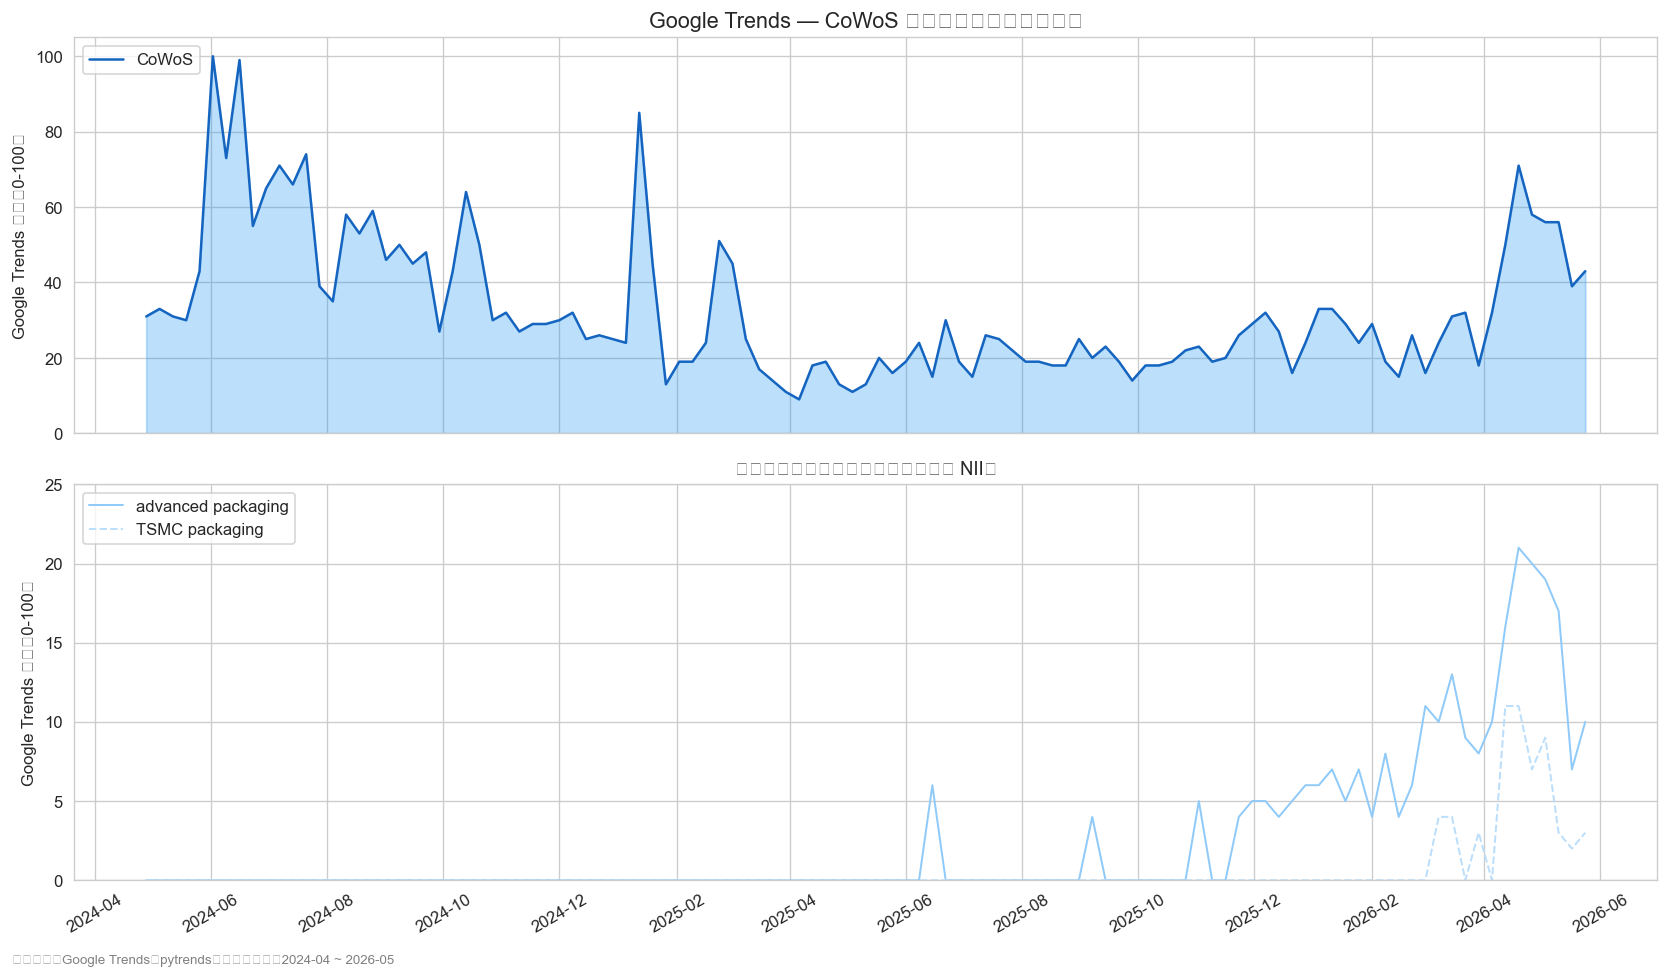

觀察：'advanced packaging' 和 'TSMC packaging' 熱度極低（幾乎為 0），NII 計算僅採用 trends_CoWoS


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 上圖：CoWoS（主力訊號）
ax1 = axes[0]
ax1.fill_between(trends.index, trends["trends_CoWoS"], alpha=0.3, color="#2196F3")
ax1.plot(trends.index, trends["trends_CoWoS"], color="#1565C0", linewidth=1.5, label="CoWoS")
ax1.set_ylabel("Google Trends 熱度（0-100）")
ax1.set_title("Google Trends — CoWoS 搜尋熱度（台灣，週頻）", fontsize=13)
ax1.legend(loc="upper left")
ax1.set_ylim(0, 105)

# 下圖：其他英文關鍵字（幾乎沒有量，作為對比）
ax2 = axes[1]
ax2.plot(trends.index, trends["trends_advanced packaging"], color="#90CAF9", linewidth=1.2, label="advanced packaging")
ax2.plot(trends.index, trends["trends_TSMC packaging"], color="#BBDEFB", linewidth=1.2, linestyle="--", label="TSMC packaging")
ax2.set_ylabel("Google Trends 熱度（0-100）")
ax2.set_title("其他英文關鍵字（熱度極低，不列入 NII）", fontsize=11)
ax2.legend(loc="upper left")
ax2.set_ylim(0, 25)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
fig.text(0.01, -0.01, "資料來源：Google Trends（pytrends）｜時間範圍：2024-04 ~ 2026-05", fontsize=8, color="gray")
plt.savefig("../reports/eda_trends.png", bbox_inches="tight", dpi=150)
plt.show()
print("觀察：'advanced packaging' 和 'TSMC packaging' 熱度極低（幾乎為 0），NII 計算僅採用 trends_CoWoS")

## 3. 每日新聞數 — Google News + GDELT

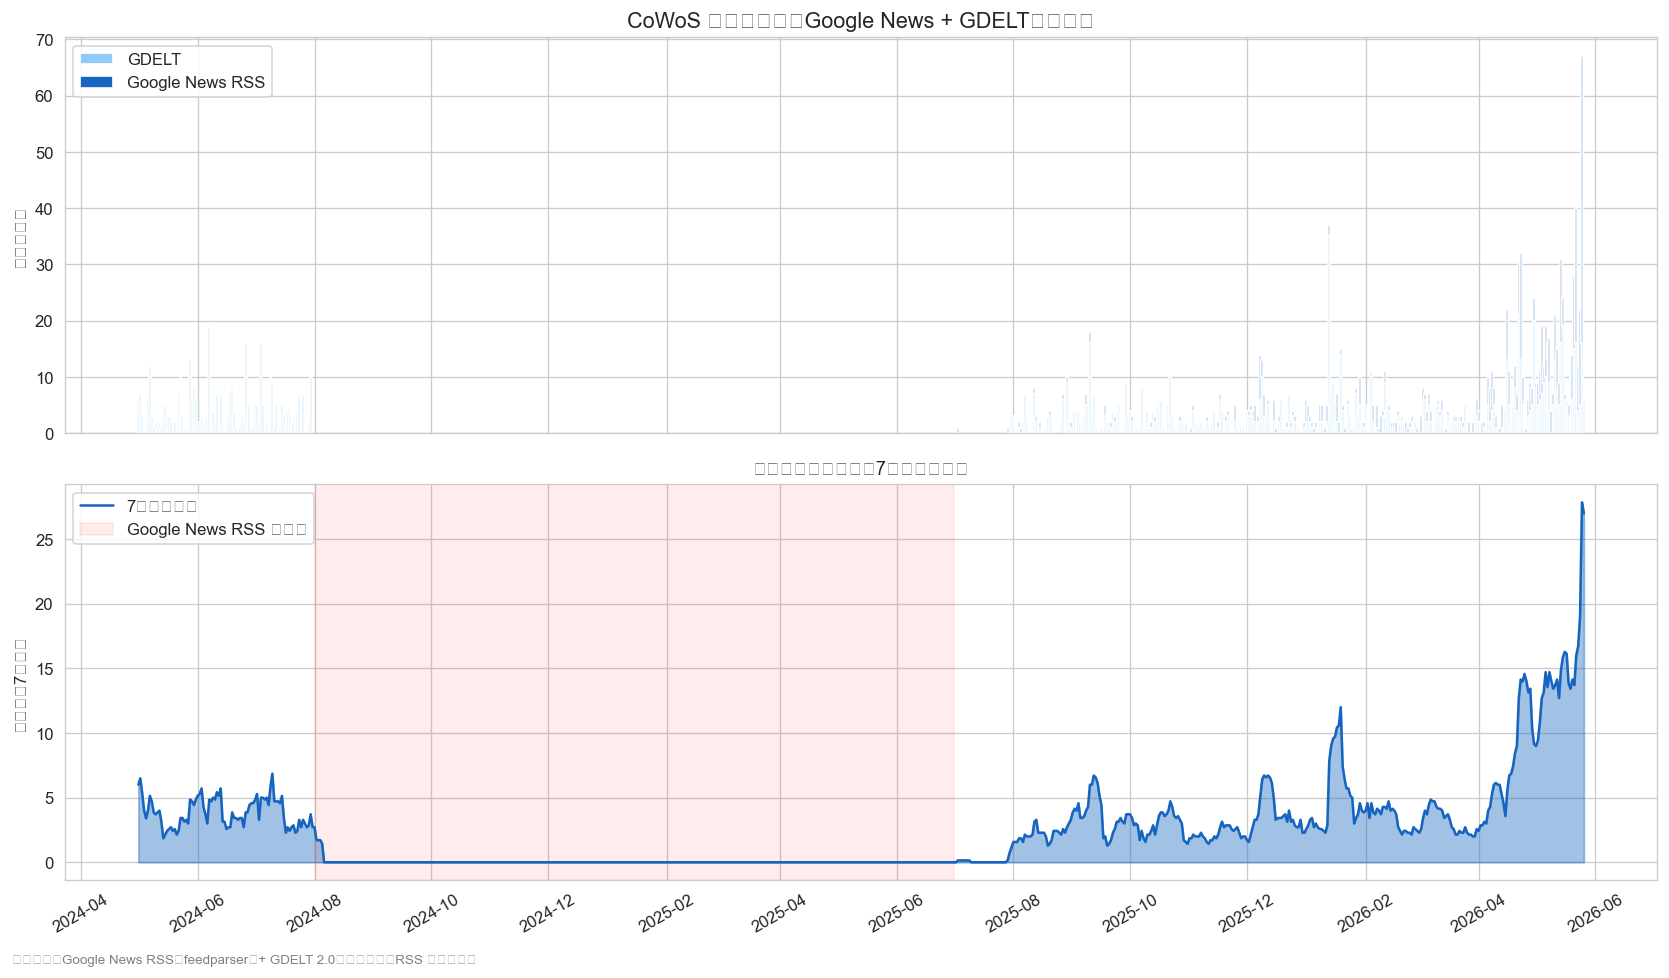

月度新聞總量（近 12 個月）：
date
2025-06-30      0
2025-07-31      9
2025-08-31     73
2025-09-30    113
2025-10-31     84
2025-11-30     64
2025-12-31    122
2026-01-31    167
2026-02-28     91
2026-03-31     99
2026-04-30    251
2026-05-31    442
Freq: ME


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 上圖：每日新聞數（堆疊）
ax1 = axes[0]
ax1.bar(daily_news.index, daily_news["gdelt_count"], label="GDELT", color="#90CAF9", width=1)
ax1.bar(daily_news.index, daily_news.get("googlenews_count", 0),
        bottom=daily_news["gdelt_count"], label="Google News RSS", color="#1565C0", width=1)
ax1.set_ylabel("每日文章數")
ax1.set_title("CoWoS 每日新聞數（Google News + GDELT，堆疊）", fontsize=13)
ax1.legend(loc="upper left")

# 下圖：7 日移動平均，讓趨勢更清楚
ax2 = axes[1]
ma7 = daily_news["total_count"].resample("D").sum().fillna(0).rolling(7, min_periods=1).mean()
ax2.fill_between(ma7.index, ma7, alpha=0.4, color="#1565C0")
ax2.plot(ma7.index, ma7, color="#1565C0", linewidth=1.5, label="7日移動平均")
ax2.set_ylabel("文章數（7日均）")
ax2.set_title("每日新聞熱度趨勢（7日移動平均）", fontsize=11)
ax2.legend(loc="upper left")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

# 標注資料覆蓋空白區
ax2.axvspan(pd.Timestamp("2024-08-01"), pd.Timestamp("2025-07-01"),
            alpha=0.07, color="red", label="Google News RSS 無資料")
ax2.legend(loc="upper left")

plt.tight_layout()
fig.text(0.01, -0.01, "資料來源：Google News RSS（feedparser）+ GDELT 2.0｜紅色區域：RSS 不覆蓋期間", fontsize=8, color="gray")
plt.savefig("../reports/eda_news.png", bbox_inches="tight", dpi=150)
plt.show()

# 月度彙整
print("月度新聞總量（近 12 個月）：")
print(daily_news["total_count"].resample("ME").sum().tail(12).to_string())

## 4. 各標的股價走勢

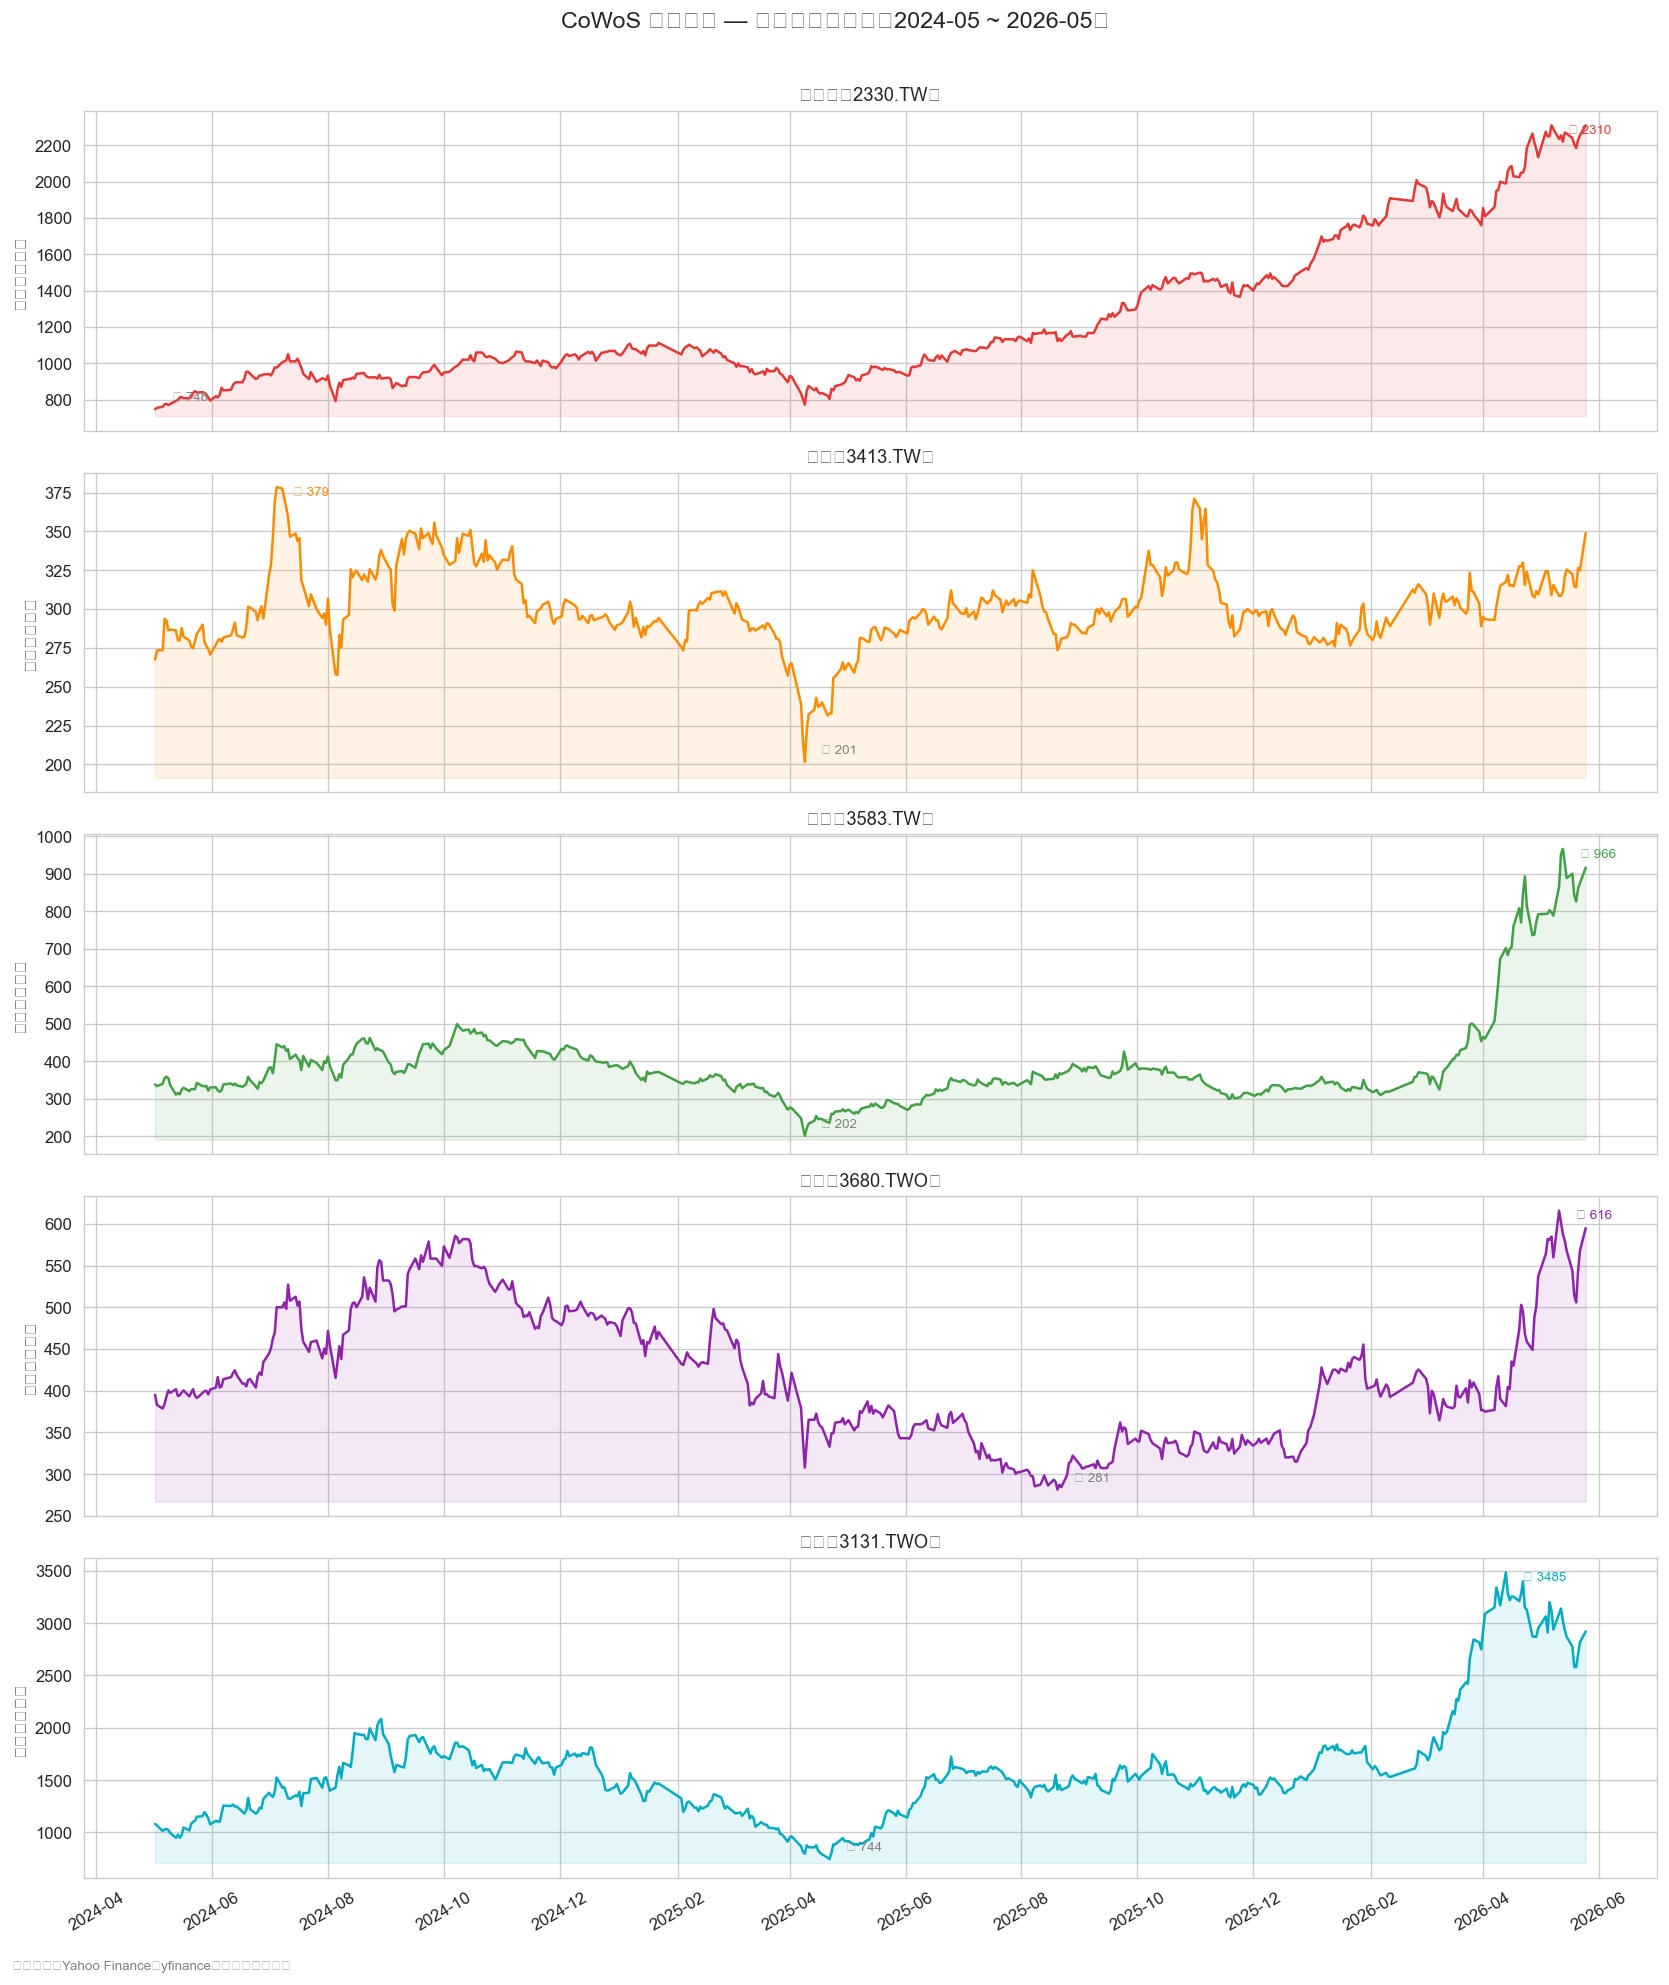

In [5]:
STOCK_TICKERS = [t for t in TICKERS if t != "^TWII"]
COLORS = {"2330.TW": "#E53935", "3413.TW": "#FB8C00", "3583.TW": "#43A047",
          "3680.TWO": "#8E24AA", "3131.TWO": "#00ACC1"}

fig, axes = plt.subplots(len(STOCK_TICKERS), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, STOCK_TICKERS):
    df = prices[ticker]
    color = COLORS[ticker]
    ax.plot(df.index, df["close"], color=color, linewidth=1.5)
    ax.fill_between(df.index, df["close"], df["close"].min() * 0.95, alpha=0.1, color=color)
    ax.set_ylabel("收盤價（元）")
    ax.set_title(f"{TICKERS[ticker]}（{ticker}）", fontsize=11)
    # 標出最高最低點
    idx_max = df["close"].idxmax()
    idx_min = df["close"].idxmin()
    ax.annotate(f"高 {df['close'].max():.0f}", xy=(idx_max, df["close"].max()),
                xytext=(10, -5), textcoords="offset points", fontsize=8, color=color)
    ax.annotate(f"低 {df['close'].min():.0f}", xy=(idx_min, df["close"].min()),
                xytext=(10, 5), textcoords="offset points", fontsize=8, color="gray")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.suptitle("CoWoS 相關標的 — 個股收盤價走勢（2024-05 ~ 2026-05）", fontsize=14, y=1.01)
plt.tight_layout()
fig.text(0.01, -0.01, "資料來源：Yahoo Finance（yfinance，調整後收盤價）", fontsize=8, color="gray")
plt.savefig("../reports/eda_prices.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. 初步疊圖：CoWoS Trends × 台積電股價

第一眼觀察訊號是否存在。

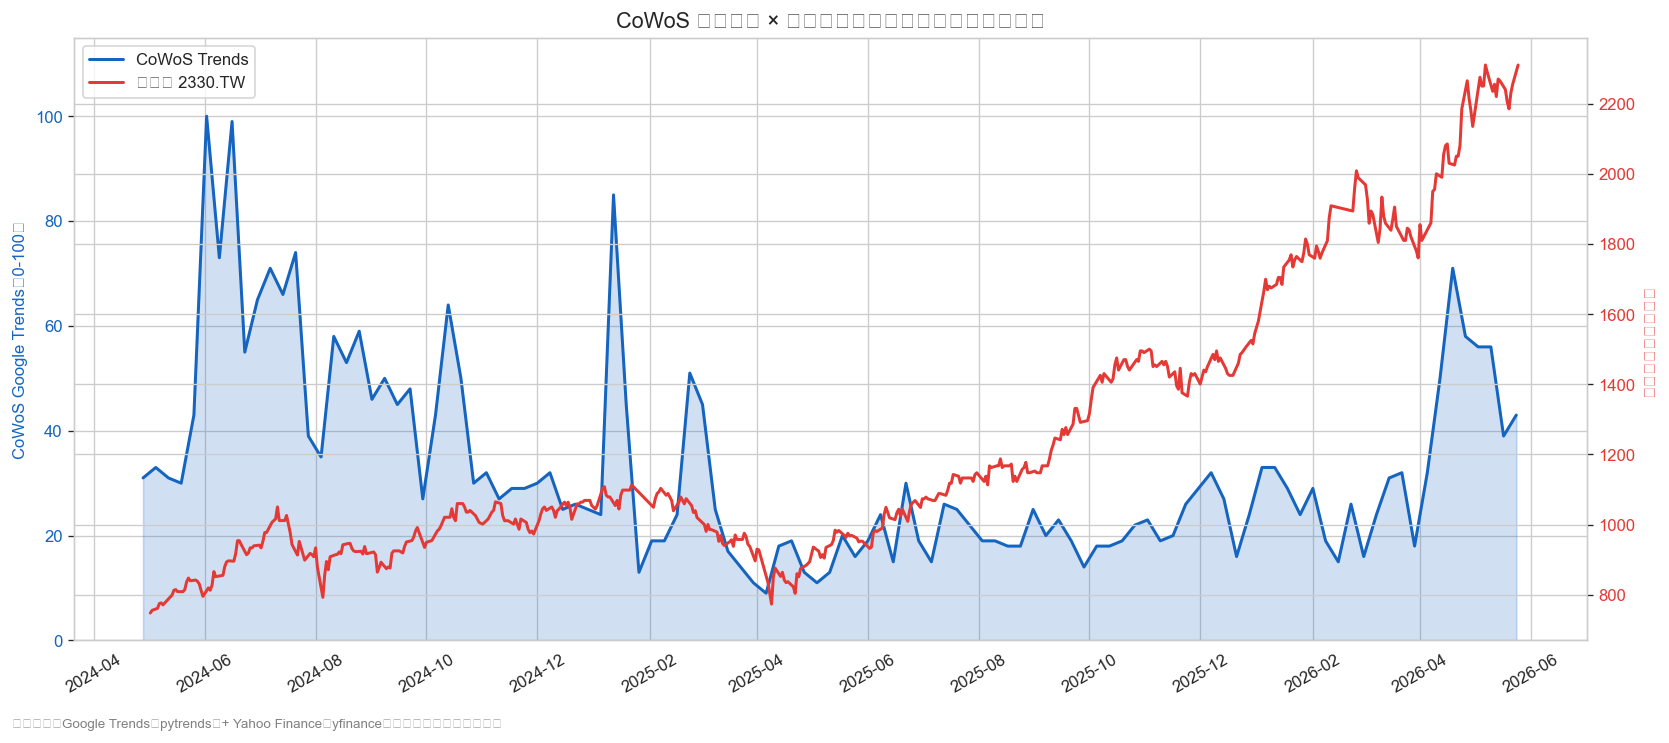

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# 左軸：CoWoS Trends（藍色系）
color_trends = "#1565C0"
ax1.set_ylabel("CoWoS Google Trends（0-100）", color=color_trends)
ax1.fill_between(trends.index, trends["trends_CoWoS"], alpha=0.2, color=color_trends)
ax1.plot(trends.index, trends["trends_CoWoS"], color=color_trends, linewidth=1.8,
         label="CoWoS Trends", zorder=2)
ax1.tick_params(axis="y", labelcolor=color_trends)
ax1.set_ylim(0, 115)

# 右軸：台積電股價（橘紅色系）
ax2 = ax1.twinx()
color_price = "#E53935"
tsmc = prices["2330.TW"]["close"]
ax2.set_ylabel("台積電收盤價（元）", color=color_price)
ax2.plot(tsmc.index, tsmc, color=color_price, linewidth=1.8, label="台積電 2330.TW", zorder=3)
ax2.tick_params(axis="y", labelcolor=color_price)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

# 合併 legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("CoWoS 搜尋熱度 × 台積電股價（雙軸疊圖，初步觀察）", fontsize=13)
fig.text(0.01, -0.02,
         "資料來源：Google Trends（pytrends）+ Yahoo Finance（yfinance）｜"
         "注意：相關不等於因果", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../reports/eda_overlay_tsmc.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. 標準化後的全標的 Trends 比較

將各標的股價標準化（以第一天為基準 = 100），疊在 CoWoS Trends 上，比較相對強弱。

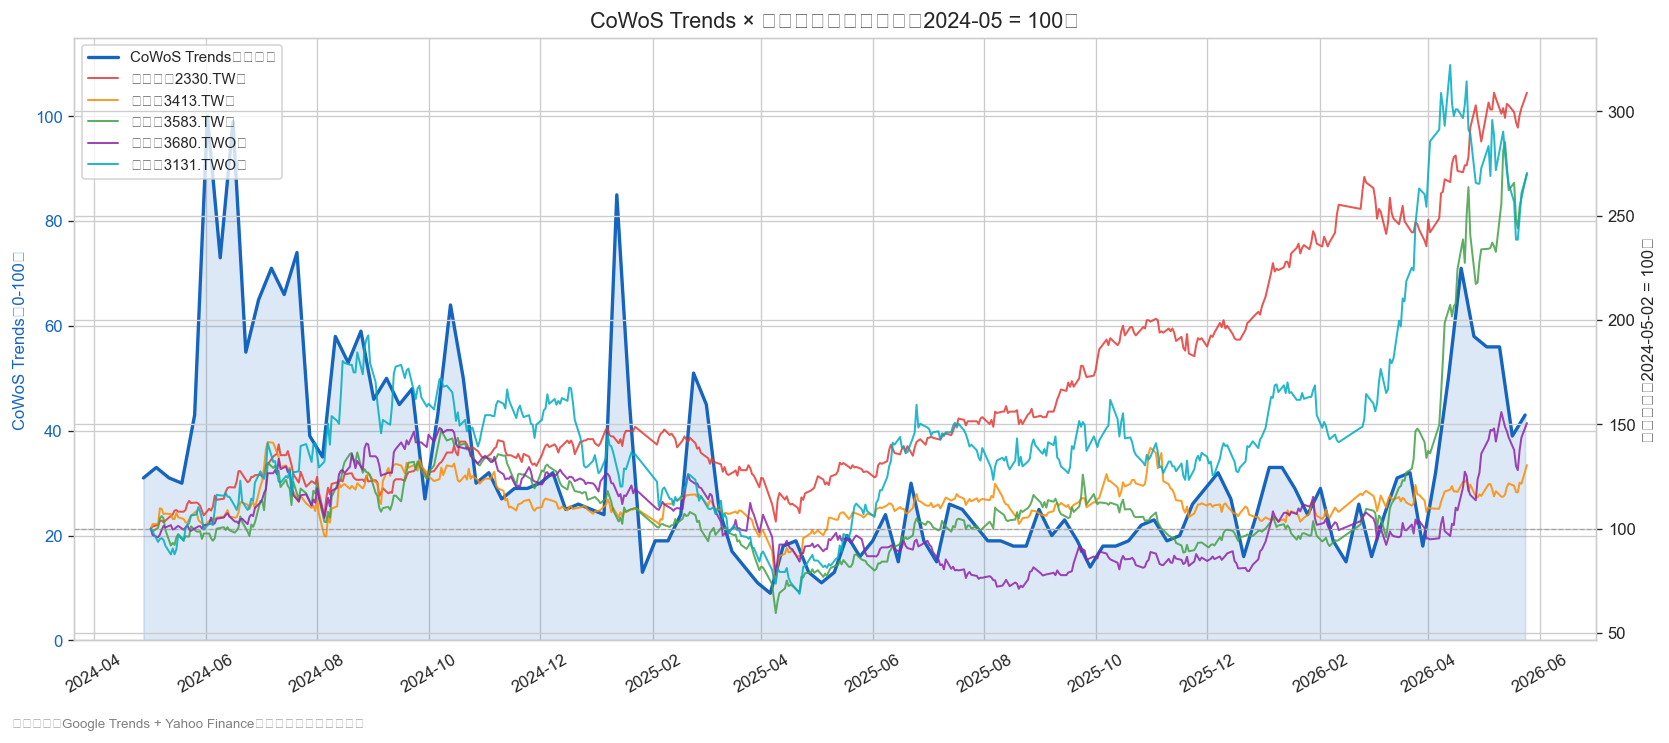

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# 左軸：CoWoS Trends
color_trends = "#1565C0"
ax1.fill_between(trends.index, trends["trends_CoWoS"], alpha=0.15, color=color_trends)
ax1.plot(trends.index, trends["trends_CoWoS"], color=color_trends, linewidth=2,
         label="CoWoS Trends（左軸）", zorder=5)
ax1.set_ylabel("CoWoS Trends（0-100）", color=color_trends)
ax1.tick_params(axis="y", labelcolor=color_trends)
ax1.set_ylim(0, 115)

# 右軸：各標的標準化股價（以 2024-05-02 為基準 = 100）
ax2 = ax1.twinx()
for ticker, name in TICKERS.items():
    if ticker == "^TWII":
        continue
    close = prices[ticker]["close"].copy()
    base = close.iloc[0]
    normalized = (close / base) * 100
    ax2.plot(normalized.index, normalized, color=COLORS[ticker],
             linewidth=1.2, alpha=0.85, label=f"{name}（{ticker}）")

ax2.set_ylabel("股價指數（2024-05-02 = 100）")
ax2.axhline(100, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.title("CoWoS Trends × 各受惠股標準化走勢（2024-05 = 100）", fontsize=13)
fig.text(0.01, -0.02, "資料來源：Google Trends + Yahoo Finance｜注意：相關不等於因果", fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../reports/eda_overlay_all.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. 資料品質：缺漏值與覆蓋檢查

In [8]:
print("=" * 55)
print("股價缺漏值檢查（應均為 0）")
print("=" * 55)
for ticker in TICKERS:
    df = prices[ticker]
    nulls = df["close"].isna().sum()
    print(f"  {ticker:12s}  缺漏：{nulls} 筆")

print()
print("=" * 55)
print("Google Trends 統計（主要用 trends_CoWoS）")
print("=" * 55)
print(trends["trends_CoWoS"].describe().round(1))

print()
print("=" * 55)
print("新聞每日數統計")
print("=" * 55)
print(daily_news.describe().round(1))

# 確認 Trends 與新聞的日期範圍是否與股價對齊
PRICE_START = prices["2330.TW"].index.min()
PRICE_END   = prices["2330.TW"].index.max()
print(f"\n股價期間：{PRICE_START.date()} ~ {PRICE_END.date()}")
print(f"Trends 期間：{trends.index.min().date()} ~ {trends.index.max().date()}")
print(f"新聞期間：{daily_news.index.min().date()} ~ {daily_news.index.max().date()}")
print()
print("⚠️  Trends 為週頻，需在 processors/alignment.py 內插至日頻")
print("⚠️  新聞 2024-08 ~ 2025-07 只有 GDELT 的 'advanced packaging' 覆蓋，CoWoS 專屬新聞稀疏")

股價缺漏值檢查（應均為 0）
  ^TWII         缺漏：0 筆
  2330.TW       缺漏：0 筆
  3413.TW       缺漏：0 筆
  3583.TW       缺漏：0 筆
  3680.TWO      缺漏：0 筆
  3131.TWO      缺漏：0 筆

Google Trends 統計（主要用 trends_CoWoS）
count    109.0
mean      32.9
std       18.8
min        9.0
25%       19.0
50%       27.0
75%       43.0
max      100.0
Name: trends_CoWoS, dtype: float64

新聞每日數統計
       googlenews_count  gdelt_count  total_count
count             341.0        341.0        341.0
mean                1.5          4.0          5.5
std                 3.9          4.1          6.6
min                 0.0          0.0          1.0
25%                 0.0          1.0          2.0
50%                 0.0          3.0          4.0
75%                 1.0          5.0          6.0
max                51.0         35.0         67.0

股價期間：2024-05-02 ~ 2026-05-25
Trends 期間：2024-04-28 ~ 2026-05-24
新聞期間：2024-05-01 ~ 2026-05-26

⚠️  Trends 為週頻，需在 processors/alignment.py 內插至日頻
⚠️  新聞 2024-08 ~ 2025-07 只有 GDELT 的 'advanced packaging

## 8. 初步相關係數（原始，未對齊）

用最簡單的方法先看看 Trends（週資料 forward-fill 到日頻）和各股價的皮爾森相關，作為基準數字。Phase 1 正式分析會在對齊後重算。

In [9]:
from scipy import stats

# Trends 週頻 forward-fill 到日頻
trends_daily = trends["trends_CoWoS"].resample("D").last().ffill()

corr_rows = []
for ticker, name in TICKERS.items():
    if ticker == "^TWII":
        continue
    close = prices[ticker]["close"]
    # 對齊日期
    common = trends_daily.index.intersection(close.index)
    t = trends_daily.loc[common]
    p = close.loc[common]
    r, pval = stats.pearsonr(t, p)
    corr_rows.append({"代號": ticker, "名稱": name, "皮爾森 r": round(r, 3),
                       "p-value": round(pval, 4), "樣本數": len(common)})

corr_df = pd.DataFrame(corr_rows).sort_values("皮爾森 r", ascending=False)
print("CoWoS Trends × 各股收盤價 — 皮爾森相關（未對齊，僅供參考）")
print(corr_df.to_string(index=False))
print()
print("注意：此為原始相關，未做：(1) 交易日對齊  (2) 去趨勢  (3) 報酬率轉換")
print("正式分析請見 02_phase1_cowos_analysis.ipynb")

CoWoS Trends × 各股收盤價 — 皮爾森相關（未對齊，僅供參考）
      代號  名稱  皮爾森 r  p-value  樣本數
3680.TWO  家登  0.537    0.000  498
 3583.TW  辛耘  0.395    0.000  498
 3413.TW  京鼎  0.352    0.000  498
3131.TWO  弘塑  0.256    0.000  498
 2330.TW 台積電 -0.029    0.516  498

注意：此為原始相關，未做：(1) 交易日對齊  (2) 去趨勢  (3) 報酬率轉換
正式分析請見 02_phase1_cowos_analysis.ipynb


## 9. EDA 小結

依照此 EDA 的觀察，整理幾個重點給後續分析：

| 面向 | 觀察 |
|------|------|
| **訊號質量** | `trends_CoWoS` 訊號清楚（max=100），其餘英文關鍵字幾乎無搜尋量 |
| **新聞覆蓋** | 2024-08 ~ 2025-07 新聞主要靠 GDELT 的「advanced packaging」關鍵字；CoWoS 專屬新聞在此段稀疏 |
| **股價** | 所有標的完整，無缺漏；2024-07 附近有明顯高峰後修正 |
| **待確認** | Trends（週）→ 日頻對齊方式；新聞稀疏段對 NII 的影響 |

**下一步**：`processors/alignment.py` + `processors/intensity.py` → `02_phase1_cowos_analysis.ipynb`

# CoWoS 訊息強度 × 股價 — 資料探索（EDA）

**目標**：確認各資料源的品質、覆蓋範圍，肉眼初步觀察訊號。

**資料來源**：
- Google Trends（週頻，2024-05 ~ 2026-05）
- Google News RSS + GDELT 每日新聞數（2024-05 ~ 2026-05）
- yfinance 台股日頻股價（2024-05 ~ 2026-05）

> ⚠️ 資料覆蓋限制：Google News RSS 只有近 12 個月；GDELT CoWoS 關鍵字只有 2024-05~07 完整，後續受限流影響較稀疏。詳見 `decisions.md` D005。